<a href="https://colab.research.google.com/github/lolndo/Basic_Networks2/blob/main/%D0%91%D0%B0%D0%B7%D0%BE%D0%B2%D1%8B%D0%B9_%D0%B1%D0%BB%D0%BE%D0%BA_%D0%9E%D0%B1%D1%83%D1%87%D0%B0%D1%8E%D1%89%D0%B0%D1%8F%2C_%D0%BF%D1%80%D0%BE%D0%B2%D0%B5%D1%80%D0%BE%D1%87%D0%BD%D0%B0%D1%8F_%D0%B8_%D1%82%D0%B5%D1%81%D1%82%D0%BE%D0%B2%D0%B0%D1%8F_%D0%B2%D1%8B%D0%B1%D0%BE%D1%80%D0%BA%D0%B8_%D0%9F%D0%B5%D1%80%D0%B5%D0%BE%D0%B1%D1%83%D1%87%D0%B5%D0%BD%D0%B8%D0%B5_%D0%9D%D0%A1_%D0%94%D0%97_Pro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Задание

Используя модуль **datasets** библиотеки **sklearn**, загрузите базу вин (`.load_wine()`).

Используя шаблон ноутбука, выполните загрузку, подготовку и предобработку данных. Обязательное условие: разделение данных на три выборки осуществляется по шаблону (изменять параметры подготовки данных запрещается)!

Проведите серию экспериментов и добейтесь максимальной точности классификации на тестовой выборке выше 94%.

---

С помощью метода `.summary()` зафиксируйте количество параметров созданной вами нейронной сети.


#Шаблон ноутбука

In [ ]:
# Последовательная модель НС
from tensorflow.keras.models import Sequential

# Основные слои
from tensorflow.keras.layers import Dense, Activation, Dropout, BatchNormalization

# Утилиты для to_categorical()
from tensorflow.keras import utils

# Алгоритмы оптимизации для обучения модели
from tensorflow.keras.optimizers import Adam

# Библиотека для работы с массивами
import numpy as np

# Отрисовка графиков
import matplotlib.pyplot as plt

# Разделение данных на выборки
from sklearn.model_selection import train_test_split

# Для загрузки датасета
from sklearn.datasets import load_wine

# Отрисовка изображений в ноутбуке, а не в консоли или файле
%matplotlib inline

##Описание базы

1. Датасет состоит из набора данных о винах и их классах.
2. Данные по одному вину хранятся в numpy-массиве `x_data`: (`13` параметров).
3. В датасете `3` класса вин: `y_data`.
4. Количество примеров: `178`.

In [ ]:
x_data = load_wine()['data']              # Загрузка набора данных о винах
y_data = load_wine()['target']            # Загрузка классов вин

print('Размерность x_data -', x_data.shape)
print('Размерность y_data -', y_data.shape)
print()

# Вывод примера данных
print('Данные по первому вину:',x_data[0])
print('Класс вина:',y_data[0])

Размерность x_data - (178, 13)
Размерность y_data - (178,)

Данные по первому вину: [1.423e+01 1.710e+00 2.430e+00 1.560e+01 1.270e+02 2.800e+00 3.060e+00
 2.800e-01 2.290e+00 5.640e+00 1.040e+00 3.920e+00 1.065e+03]
Класс вина: 0


##Подготовка данных

In [ ]:
# Перевод в one hot encoding
y_data = utils.to_categorical(y_data, 3)

# Разбиение наборов на общую и тестовую выборки
x_all, x_test, y_all, y_test = train_test_split(x_data,
                                                y_data,
                                                test_size=0.1,
                                                shuffle=True,
                                                random_state = 6)

# Разбиение общей выборки на обучающую и проверочную
x_train, x_val, y_train, y_val = train_test_split(x_all,
                                                  y_all,
                                                  test_size=0.1,
                                                  shuffle=True,
                                                  random_state = 6)

print(x_train.shape)
print(y_train.shape)
print()
print(x_val.shape)
print(y_val.shape)

(144, 13)
(144, 3)

(16, 13)
(16, 3)


In [ ]:
# ваше решение

In [ ]:
#Нормализация данных
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled = scaler.transform(x_val)
x_test_scaled = scaler.transform(x_test)

Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8125 - loss: 0.7271 - val_accuracy: 0.8125 - val_loss: 0.6973
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9097 - loss: 0.5563 - val_accuracy: 0.8125 - val_loss: 0.5712
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9306 - loss: 0.4335 - val_accuracy: 0.8125 - val_loss: 0.4760
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9375 - loss: 0.3463 - val_accuracy: 0.8125 - val_loss: 0.4072
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9514 - loss: 0.2817 - val_accuracy: 0.8750 - val_loss: 0.3589
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9653 - loss: 0.2351 - val_accuracy: 0.8750 - val_loss: 0.3238
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9722 - loss: 0.1976 - val_accuracy: 0.8750 - val_loss: 0.2976
Epoch 8/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9861 - loss: 0.1697 - val_accuracy: 0.8750 - val_loss

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,643 (6.42 KB)

 Trainable params: 547 (2.14 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,096 (4.29 KB)

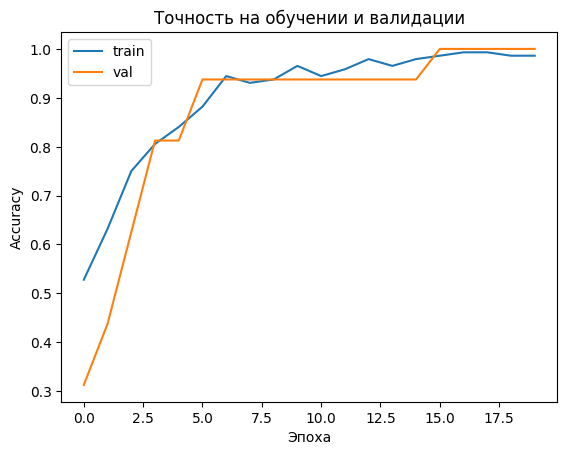

In [ ]:
#перебор архитектур
import itertools

hidden_sizes = [32, 64, 128, 256]       # размер первого скрытого слоя
num_layers = [1, 2]                     # количество скрытых слоёв
dropout_rates = [0.0, 0.3, 0.5]        # уровень Dropout

best_val_acc = 0
best_model = None
best_params = None
best_history = None

for size, n_layers, dr in itertools.product(hidden_sizes, num_layers, dropout_rates):
    model = Sequential()
    model.add(Dense(size, input_dim=13, activation='relu'))
    if dr > 0:
        model.add(Dropout(dr))
    for i in range(n_layers-1):
        model.add(Dense(size // 2, activation='relu'))
        if dr > 0:
            model.add(Dropout(dr))
    model.add(Dense(3, activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(x_train_scaled, y_train,
                        validation_data=(x_val_scaled, y_val),
                        epochs=20, batch_size=8, verbose=1)

    val_acc = max(history.history['val_accuracy'])  # лучшая точность на валидации за все эпохи

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model = model
        best_params = (size, n_layers, dr)
        best_history = history

print(f"Лучшая валидационная точность: {best_val_acc:.4f}")
print(f"Параметры: первый слой={best_params[0]}, слоёв={best_params[1]}, dropout={best_params[2]}")

# 3. Оценка лучшей модели на тестовой выборке
test_loss, test_acc = best_model.evaluate(x_test_scaled, y_test, verbose=0)
print(f"Тестовая точность: {test_acc:.4f}")

# 4. Вывод архитектуры и количества параметров
best_model.summary()

# Дополнительно: график процесса обучения лучшей модели
import matplotlib.pyplot as plt
plt.plot(best_history.history['accuracy'], label='train')
plt.plot(best_history.history['val_accuracy'], label='val')
plt.title('Точность на обучении и валидации')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.show()